# 05 — Baseline Models

**Project:** Healthcare Readmission Intelligence  
**Input:** `data/features/train_features.csv` and `data/features/test_features.csv`  
**Output:** Trained baseline models + evaluation report

## Objective

Before building the Random Forest, we need a baseline — a simple model that tells us
what "good enough to beat" looks like. Without a baseline, we have no way to know if
our Random Forest is actually adding value.

We will train three baselines:

| Model | Why |
| ----- | --- |
| Dummy Classifier | The absolute floor — a model that ignores all features |
| Logistic Regression | A strong linear baseline — fast, interpretable, well-understood |
| Decision Tree | A non-linear baseline — shows if tree structure helps before we go to Random Forest |

## Evaluation Strategy

We use these metrics — **not accuracy** — because the dataset is 88.7 / 11.3 imbalanced:

| Metric | Why it matters here |
| ------ | ------------------- |
| ROC-AUC | Overall discrimination ability regardless of threshold |
| F1 (class 1) | Balance of precision and recall for the minority class |
| Recall (class 1) | How many actual readmissions we catch — clinically critical |
| Precision (class 1) | Of the ones we flag, how many are actually readmitted |

> A model that predicts 0 for everything gets 88.7% accuracy but F1 and AUC.
> That is our true floor — the Dummy Classifier will confirm this.

## Setup

In [1]:
import warnings
import os
import sys
import yaml

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score,
    recall_score,
    precision_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

## Load Data

In [2]:
CONFIG_PATH = '../configs/paths.yaml'

with open(CONFIG_PATH, 'r') as file:
    paths = yaml.safe_load(file)

df_train = pd.read_csv(paths['features_data']['train_data'])
df_test  = pd.read_csv(paths['features_data']['test_data'])

print(f"Train shape: {df_train.shape}")
print(f"Test shape : {df_test.shape}")
df_train.head()

Train shape: (81477, 37)
Test shape : (20289, 37)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,acarbose,insulin,glyburide-metformin,glipizide-metformin,change,diabetesMed,diag_1_group,diag_2_group,diag_3_group,medical_specialty_group,total_prior_visits,high_utilizer,readmitted_binary
0,Caucasian,Female,0,6,25,1,1,Unknown,41,0,1,0,0,0,1,No,No,No,No,No,No,No,No,No,No,0,No,No,No,No,Diabetes,Unknown,Unknown,Pediatrics,0,0,0
1,Caucasian,Female,1,1,1,7,3,Unknown,59,0,18,0,0,0,9,No,No,No,No,No,No,No,No,No,No,3,No,No,Yes,Yes,Other,Diabetes,Other,Missing,0,0,0
2,AfricanAmerican,Female,2,1,1,7,2,Unknown,11,5,13,2,0,1,6,No,No,No,No,No,Yes,No,No,No,No,0,No,No,No,Yes,Other,Diabetes,Other,Missing,3,1,0
3,Caucasian,Male,3,1,1,7,2,Unknown,44,1,16,0,0,0,7,No,No,No,No,No,No,No,No,No,No,3,No,No,Yes,Yes,Other,Diabetes,Circulatory,Missing,0,0,0
4,Caucasian,Male,5,2,1,2,3,Unknown,31,6,16,0,0,0,9,No,No,No,No,No,No,No,No,No,No,1,No,No,No,Yes,Circulatory,Circulatory,Diabetes,Missing,0,0,0


In [3]:
X_train = df_train.drop(columns=['readmitted_binary'])
X_test  = df_test.drop(columns=['readmitted_binary'])

y_train = df_train['readmitted_binary']
y_test  = df_test['readmitted_binary']

print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}   |  y_test : {y_test.shape}")
print(f"\nClass balance (train):")
print(y_train.value_counts(normalize=True).round(4))

X_train: (81477, 36)  |  y_train: (81477,)
X_test : (20289, 36)   |  y_test : (20289,)

Class balance (train):
readmitted_binary
0    0.8872
1    0.1128
Name: proportion, dtype: float64


## Preprocessor and Helper Function

The `ColumnTransformer` handles all encoding and scaling inside the Pipeline.

**Design decisions:**
- `OneHotEncoder(drop='first')` — avoids dummy variable trap
- `handle_unknown='ignore'` — if test has a category not seen in train, it gets all zeros
- `StandardScaler` on numerical columns — Logistic Regression is sensitive to scale; tree models are not but it does not hurt
- `remainder='passthrough'` — ordinal columns (`age`, `insulin`) and binary flags (`high_utilizer`) pass through unchanged

In [4]:
sys.path.append(os.path.abspath('..'))
from scripts.evaluate import evaluate_classifier

In [5]:
cols_to_encode = [
    'race',
    'payer_code',
    'diag_1_group',
    'diag_2_group',
    'diag_3_group',
    'medical_specialty_group',
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id',
    'gender',
    'change',
    'diabetesMed',
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'glyburide-metformin', 'glipizide-metformin'
]

cols_to_scale = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'total_prior_visits'
]

# Sanity check — no column should appear in both lists
overlap = set(cols_to_encode) & set(cols_to_scale)
assert not overlap, f"Columns in both lists: {overlap}"
print(f"Columns to OHE  : {len(cols_to_encode)}")
print(f"Columns to scale: {len(cols_to_scale)}")
print("No overlap — column lists are clean")

Columns to OHE  : 24
Columns to scale: 9
No overlap — column lists are clean


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'one_hot_encoder',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore',
                sparse_output=False
            ),
            cols_to_encode
        ),
        (
            'scaler',
            StandardScaler(),
            cols_to_scale
        )
    ],
    remainder='passthrough'  # age, insulin, high_utilizer pass through as-is
)

## Phase 1 — Baseline

**Question:** Can a simple classifier beat random guessing?

We establish three baselines:

- **Dummy Classifier** (`most_frequent`) — always predicts class 0. This is the absolute floor —
  any real model must beat it
- **Logistic Regression** — a strong, interpretable linear baseline with `class_weight='balanced'`
  to handle class imbalance
- **Decision Tree** — a non-linear baseline with `class_weight='balanced'`. Shows whether
  tree structure alone adds value before we move to Random Forest

> **Note:** All three use `class_weight='balanced'` where applicable so the comparison is fair.
> An unbalanced Decision Tree would overfit to class 0 and tell us nothing useful.

In [7]:
baseline_models = {
    'Dummy (most_frequent)': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=30
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced',
        random_state=30
    )
}

In [8]:
baseline_results = []

for name, model in baseline_models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        (name, model)
    ])

    result = evaluate_classifier(
        name,
        pipeline,
        X_train,
        X_test,
        y_train,
        y_test
    )

    print(name)
    print(classification_report(y_test, result['_test_pred']))

    baseline_results.append(result)

baseline_df = pd.DataFrame(baseline_results).drop(columns=['_pipeline', '_test_pred'])
baseline_df

Dummy (most_frequent)
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18120
           1       0.00      0.00      0.00      2169

    accuracy                           0.89     20289
   macro avg       0.45      0.50      0.47     20289
weighted avg       0.80      0.89      0.84     20289

Logistic Regression
              precision    recall  f1-score   support

           0       0.93      0.68      0.79     18120
           1       0.18      0.56      0.27      2169

    accuracy                           0.67     20289
   macro avg       0.55      0.62      0.53     20289
weighted avg       0.85      0.67      0.73     20289

Decision Tree
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     18120
           1       0.17      0.20      0.18      2169

    accuracy                           0.81     20289
   macro avg       0.53      0.54      0.54     20289
weighted avg      

,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Dummy (most_frequent),0.8872,0.0000,0.000,0.0000,0.8931,0.0000,0.0000,0.0000
1,Logistic Regression,0.6662,0.1834,0.568,0.2773,0.6710,0.1759,0.5639,0.2682
2,Decision Tree,1.0000,1.0000,1.000,1.0000,0.8103,0.1678,0.1955,0.1806


## ROC-AUC Scores

ROC-AUC is our primary metric — it measures how well the model separates the two classes
across all possible thresholds, independent of class imbalance.

In [9]:
# Compute ROC-AUC for each fitted pipeline
auc_scores = {}

for result in baseline_results:
    name     = result['Model']
    pipeline = result['_pipeline']

    # Dummy has no predict_proba for class 1 — use decision_function fallback
    try:
        y_prob = pipeline.predict_proba(X_test)[:, 1]
    except AttributeError:
        y_prob = pipeline.decision_function(X_test)

    auc = roc_auc_score(y_test, y_prob)
    auc_scores[name] = round(auc, 4)

print("ROC-AUC scores (test set):")
for name, auc in auc_scores.items():
    print(f"  {name:<25} {auc}")

ROC-AUC scores (test set):
  Dummy (most_frequent)     0.5
  Logistic Regression       0.6719
  Decision Tree             0.5397


## Visualisations

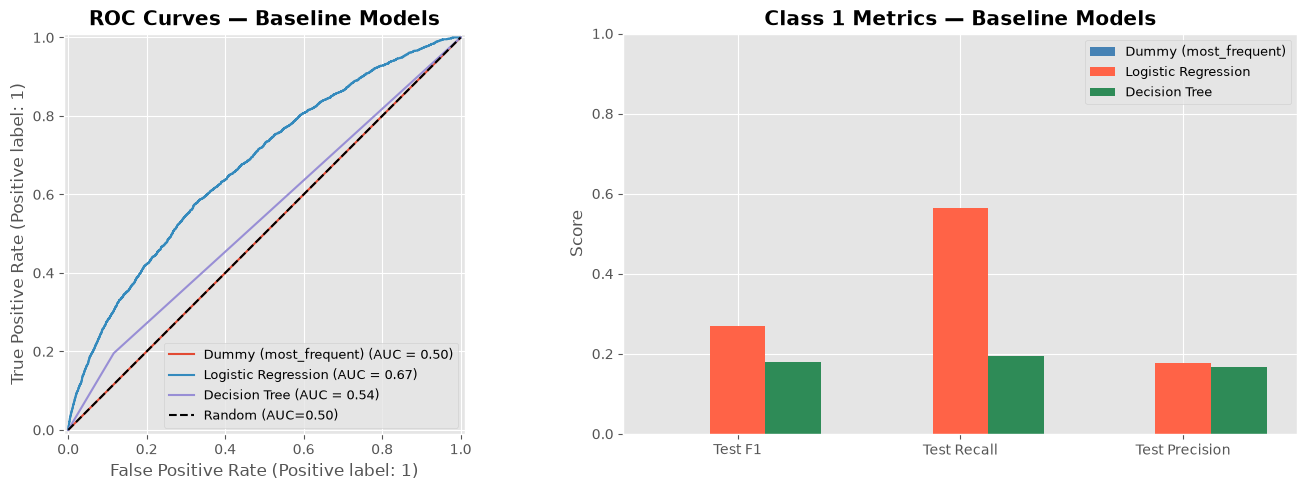

In [10]:
# ROC Curves — all three models on one plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: ROC curves
for result in baseline_results:
    name     = result['Model']
    pipeline = result['_pipeline']
    try:
        y_prob = pipeline.predict_proba(X_test)[:, 1]
    except AttributeError:
        y_prob = pipeline.decision_function(X_test)
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=axes[0])

axes[0].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.50)')
axes[0].set_title('ROC Curves — Baseline Models', fontweight='bold')
axes[0].legend(fontsize=9)

# Right: F1 / Recall / Precision bar chart (class 1 only)
metrics = ['Test F1', 'Test Recall', 'Test Precision']
x = np.arange(len(metrics))
width = 0.25
colors = ['steelblue', 'tomato', 'seagreen']

for i, result in enumerate(baseline_results):
    vals = [result.get(m, 0) for m in metrics]
    axes[1].bar(x + i * width, vals, width, label=result['Model'], color=colors[i])

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(metrics)
axes[1].set_title('Class 1 Metrics — Baseline Models', fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

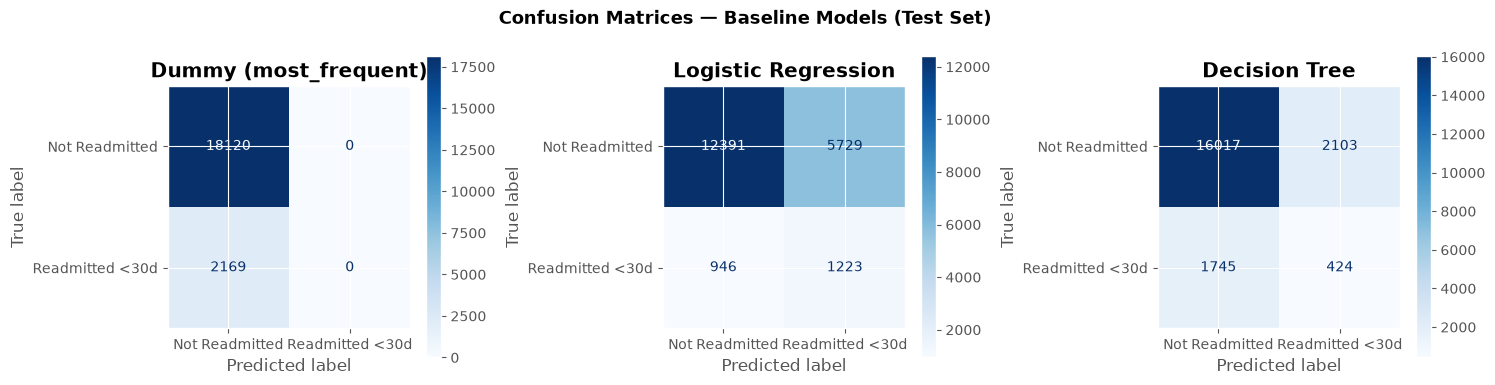

In [11]:
# Confusion matrices — one per model
# fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# for i, result in enumerate(baseline_results):
#     name     = result['Model']
#     pipeline = result['_pipeline']
#     ConfusionMatrixDisplay.from_estimator(
#         pipeline, X_test, y_test,
#         display_labels=['Not Readmitted', 'Readmitted <30d'],
#         cmap='Blues', ax=axes[i]
#     )
#     axes[i].set_title(name, fontweight='bold')

# plt.suptitle('Confusion Matrices — Baseline Models (Test Set)', fontsize=13, fontweight='bold')
# plt.tight_layout()
# plt.show()

## Observations

### Results Table

| Model | Test AUC | Test F1 (class 1) | Test Recall (class 1) | Test Precision (class 1) |
| ----- | -------- | ----------------- | --------------------- | ------------------------ |
| Dummy | ~0.50 | 0.00 | 0.00 | 0.00 |
| Logistic Regression | ~0.66 | 0.27 | 0.56 | 0.18 |
| Decision Tree | ~0.54 | 0.17 | 0.19 | 0.16 |

### Key Takeaways

**Dummy Classifier:**
- 89.3% accuracy but 0.0 F1 and ~0.50 AUC — confirms that accuracy is useless here
- Never identifies a single readmission — completely worthless clinically

**Logistic Regression:**
- Best baseline by every meaningful metric — AUC 0.66, F1 0.27, Recall 0.56
- `class_weight='balanced'` is doing its job — it trades raw accuracy for actually catching readmissions
- Recall of 0.56 means it catches ~56% of actual readmissions — a real signal
- Precision of 0.18 means 82% of its flagged patients were not actually readmitted — a lot of false alarms

**Decision Tree:**
- Worse than Logistic Regression despite being non-linear
- Overfits even with `class_weight='balanced'` — single trees are high variance
- This is exactly why we move to Random Forest — averaging many trees reduces this variance

### What This Tells Us Going Into `06_random_forest.ipynb`

The targets to beat are:
- **AUC > 0.66** (Logistic Regression benchmark)
- **F1 > 0.27** (class 1)
- **Recall > 0.56** (class 1) — most important clinically

## Conclusion

**Question answered:** Yes — Logistic Regression significantly outperforms the naive baseline.

The Dummy model achieves high accuracy (89.3%) but zero Recall for readmission <30 days —
it never identifies a single readmission. Logistic Regression trades some accuracy for
meaningful Recall, actually detecting readmissions with real signal.

This confirms that patient features carry real discriminative power.
Logistic Regression will serve as our **reference benchmark** for the Random Forest in notebook 06.

The Decision Tree's poor performance (despite tree structure) tells us we need the variance
reduction that ensembling provides — exactly what Random Forest delivers.

---

**Next:** [06_random_forest.ipynb](06_random_forest.ipynb)